# Kuperberg's Algorithm for the Dihedral HSP

Recover a hidden reflection by combining quantum phase qubits in a sieve,
then determine the reflection one binary digit at a time.

[The problem](#problem) · [Quantum section](#quantum) ·
[Classical section](#classical) · [Success and cost](#cost)

This notebook implements the basic power-of-two version, $N=2^n$.
It includes an oracle-derived Qiskit phase-state source, the quantum
combination operation, classical control of the sieve, and complete
reflection recovery on small examples.

The retained qubits are simulated as quantum states. The controller
uses their known labels and measured outcomes. The lookup oracle and
local simulation are educational implementations, with their costs
separated from Kuperberg's asymptotic algorithm.

<a id="problem"></a>
## 1. The problem

Use the convention

$$
D_N=\{(x,b):x\in\mathbb Z_N,\ b\in\mathbb Z_2\},
$$

with multiplication

$$
(x,b)(y,c)=\bigl(x+(-1)^b y\bmod N,\ b+c\bmod2\bigr).
$$

The group has $2N$ elements. The elements $(x,0)$ are rotations and
$(x,1)$ are reflections. For $N\geq3$ it is nonabelian.

An unknown $s\in\{0,\ldots,N-1\}$ defines the reflection subgroup

$$
H_s=\{(0,0),(s,1)\}.
$$

We are given a function $f$ promised to be constant on each left coset
of $H_s$ and different on distinct cosets. The task is to find $s$.

The coset containing $(x,0)$ is

$$
(x,0)H_s=\{(x,0),(x+s,1)\}.
$$

Thus the promise includes $f(x,0)=f(x+s,1)$, with arithmetic modulo
$N$, and there are no other collisions between distinct group elements.

The implemented sieve assumes $N=2^n$. The recursion eventually reaches
$N=2$, which is a valid base case even though that group is abelian.
Kuperberg's paper also develops algorithms for other values of $N$.

### A concrete hiding oracle

For the examples, choose an arbitrary permutation $\pi$ of the output
labels and define

$$
f(x,b)=\pi(x-bs\bmod N).
$$

This hides exactly the cosets above. Random relabeling prevents any
interpretation of the output number as the input coordinate.

Only the instance builder receives $s$. The recovery function receives
$N$ and the oracle. Its final check is

$$
f(\widehat s,1)=f(0,0).
$$

Under the hiding promise, this equality holds exactly when
$\widehat s=s$. The simulator compiles an explicit table for small
instances. Accessing that table has a separate classical cost, so this
demonstration does not establish a black-box quantum speedup.

<a id="quantum"></a>
## 2. Quantum section

### From a coset state to a labeled phase qubit

Prepare a uniform superposition over $D_N$ and evaluate $f$ in an
output register. Measuring that output leaves a coset state

$$
\frac{\lvert x\rangle\lvert0\rangle+
      \lvert x+s\rangle\lvert1\rangle}{\sqrt2}.
$$

Let $\omega_N=e^{2\pi i/N}$. Apply the positive-exponent Fourier transform

$$
F_N\lvert x\rangle=\frac1{\sqrt N}
\sum_{k=0}^{N-1}\omega_N^{kx}\lvert k\rangle
$$

to the rotation register. The state becomes

$$
\frac1{\sqrt{2N}}\sum_{k=0}^{N-1}
\omega_N^{kx}\lvert k\rangle
\left(\lvert0\rangle+\omega_N^{ks}\lvert1\rangle\right).
$$

Measuring the rotation register gives a uniform $k\in\mathbb Z_N$ and
leaves, up to an irrelevant global phase, the qubit

$$
\lvert\psi_k\rangle
=\frac{\lvert0\rangle+\omega_N^{ks}\lvert1\rangle}{\sqrt2}.
$$

The classical label $k$ is known. Its distribution alone contains no
information about $s$. The unknown information remains in the relative
phase of the unmeasured qubit.

The output measurement commutes with the rotation-register QFT.
The code therefore performs the QFT first, then measures the output
and rotation registers together.

In [1]:
# Run this only if the dependencies are missing.
# %pip install -r requirements.txt

In [2]:
from collections import defaultdict
from dataclasses import dataclass
from math import isqrt

import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)

Qiskit: 2.5.2
NumPy: 2.5.3


In [3]:
def power_two_width(N):
    if type(N) is not int or N < 2 or N & (N - 1):
        raise ValueError("N must be a power of two at least 2.")
    return N.bit_length() - 1


def make_hidden_reflection(N, s, seed=11):
    '''Build a small promised oracle. Only the instance builder knows s.'''
    power_two_width(N)
    if type(s) is not int or not 0 <= s < N:
        raise ValueError("Require an integer 0 <= s < N.")
    permutation = np.random.default_rng(seed).permutation(N).tolist()

    def oracle(x, b):
        if type(x) is not int or not 0 <= x < N or b not in (0, 1):
            raise ValueError("Invalid dihedral element.")
        return permutation[(x - b * s) % N]

    return oracle

### Implement the reversible oracle and state preparation

The oracle acts on every output basis state by XOR evaluation:

$$
U_f\lvert x,b,w\rangle
=\lvert x,b,w\mathbin{\oplus}f(x,b)\rangle.
$$

The input is encoded as the integer $x+Nb$. For each output bit,
a Boolean Möbius transform converts the truth table to an XOR of
products of input bits. Each product becomes a controlled NOT gate.

This construction is explicit and reversible, but it uses $2N$
classical oracle evaluations for a table. In the abstract algorithm,
an efficient coherent oracle is supplied instead.

The QFT is appended as a gate decomposition, avoiding storage of a
dense Fourier matrix.

In [4]:
def compile_xor_oracle(values):
    '''Truth-table XOR oracle compiled via algebraic normal form.'''
    length = len(values)
    inputs = power_two_width(length)
    if length > 128 or any(type(v) is not int or v < 0 for v in values):
        raise ValueError("Use at most 128 nonnegative integer table entries.")
    outputs = max(1, max(values).bit_length())
    if inputs + outputs > 16:
        raise ValueError("This demonstration supports at most 16 preparation qubits.")
    coefficients = list(values)
    for bit in range(inputs):
        for mask in range(length):
            if mask & (1 << bit):
                coefficients[mask] ^= coefficients[mask ^ (1 << bit)]
    circuit = QuantumCircuit(inputs + outputs, name="dihedral_oracle")
    for mask, word in enumerate(coefficients):
        controls = [j for j in range(inputs) if mask & (1 << j)]
        for out_bit in range(outputs):
            if (word >> out_bit) & 1:
                if controls:
                    circuit.mcx(controls, inputs + out_bit)
                else:
                    circuit.x(inputs + out_bit)
    return circuit, outputs


def phase_preparation_circuit(N, oracle):
    '''Prepare the oracle output and apply the positive QFT to the rotation register.'''
    n = power_two_width(N)
    if N > 64:
        raise ValueError("The explicit lookup demonstration supports N <= 64.")
    # Input encoding is x + N*b, with b above the n rotation qubits.
    values = [oracle(x, b) for b in (0, 1) for x in range(N)]
    evaluator, m = compile_xor_oracle(values)
    rotation = QuantumRegister(n, "rotation")
    branch = QuantumRegister(1, "phase")
    output = QuantumRegister(m, "output")
    circuit = QuantumCircuit(rotation, branch, output)
    circuit.h(rotation)
    circuit.h(branch)
    circuit.append(evaluator.to_gate(label=r"$U_f$"), [*rotation, *branch, *output])
    qft = QFTGate(n).definition.to_gate(label=r"$F_N$")
    circuit.append(qft, rotation)
    return circuit, n, m

### Retain the unmeasured qubit

We use Qiskit's
[Statevector](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector)
to model partial measurements while retaining the other qubit for
later operations.

The adapter below extracts the two residual amplitudes only to represent
the unmeasured physical qubit in the simulator. The classical sieve
does not inspect those amplitudes to infer $s$.

Each call to the source represents a fresh circuit preparation and
oracle query. The simulator caches the calculation of the identical
preparation state, then samples independent measurement outcomes.
The preparation count records the fresh states required by a quantum
implementation.

In [5]:
@dataclass
class PhaseQubit:
    label: int
    state: Statevector


class CircuitPhaseSource:
    '''Simulator adapter for fresh preparations and partial measurements.'''

    def __init__(self, N, oracle, rng):
        self.N = N
        self.circuit, self.n, self.m = phase_preparation_circuit(N, oracle)
        self.prepared = Statevector.from_instruction(self.circuit)
        self.prepared.seed(rng)
        self.measured_qubits = (
            list(range(self.n)) +
            list(range(self.n + 1, self.n + 1 + self.m))
        )
        self.preparations = 0

    def sample(self):
        bits, collapsed = self.prepared.measure(self.measured_qubits)
        outcome = int(bits, 2)
        k = outcome & (self.N - 1)
        output_value = outcome >> self.n
        base = k + (output_value << (self.n + 1))
        # Extract only the unmeasured branch qubit from the collapsed simulation.
        retained = Statevector([collapsed.data[base], collapsed.data[base + self.N]])
        self.preparations += 1
        return PhaseQubit(k, retained)

### Example preparation circuit

The example uses $N=32$, so $D_N$ has $64$ elements. The instance
builder selects the hidden reflection. The recovery code will receive
only the resulting oracle.

In the circuit below, the rotation and output registers are measured.
The qubit labeled “phase” remains available for the sieve.

Some measured labels: [24, 22, 19, 16, 1, 0, 11, 14]


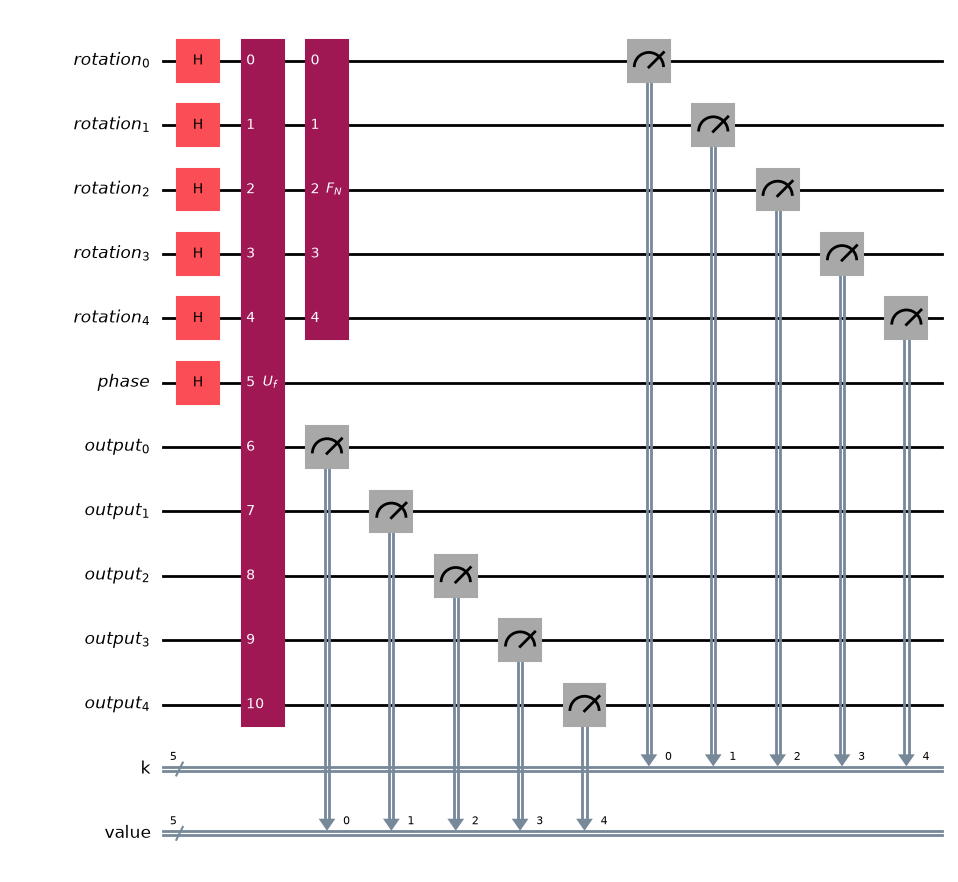

In [6]:
N = 32
hidden_s = 19  # Used only by the instance builder and the final example assertion.
oracle = make_hidden_reflection(N, hidden_s, seed=11)
demo_rng = np.random.default_rng(73)
demo_source = CircuitPhaseSource(N, oracle, demo_rng)

drawing = demo_source.circuit.copy()
frequency_bits = ClassicalRegister(demo_source.n, "k")
output_bits = ClassicalRegister(demo_source.m, "value")
drawing.add_register(frequency_bits, output_bits)
drawing.measure(list(range(demo_source.n)), frequency_bits)
drawing.measure(list(range(demo_source.n + 1,
                           demo_source.n + 1 + demo_source.m)), output_bits)
print("Some measured labels:", [demo_source.sample().label for _ in range(8)])
display(drawing.draw("mpl", fold=-1, style={"fontsize": 10}))
plt.close("all")

### Combine two phase qubits

Take two independent states $\lvert\psi_k\rangle$ and
$\lvert\psi_\ell\rangle$. In logical left-to-right qubit order,

$$
\lvert\psi_k\rangle\lvert\psi_\ell\rangle
=\frac12\left(
\lvert00\rangle+\omega_N^{\ell s}\lvert01\rangle
+\omega_N^{ks}\lvert10\rangle
+\omega_N^{(k+\ell)s}\lvert11\rangle
\right).
$$

Apply a CNOT with the first qubit controlling the second. The result is

$$
\frac1{\sqrt2}\left(
\lvert\psi_{k+\ell}\rangle\lvert0\rangle+
\omega_N^{\ell s}\lvert\psi_{k-\ell}\rangle\lvert1\rangle
\right).
$$

Measure the second qubit. Outcome $0$ leaves label $k+\ell$, while
outcome $1$ leaves label $k-\ell$, both modulo $N$. Each outcome has
probability $1/2$, independently of the hidden reflection.

This is the quantum operation used by the sieve. Both parent qubits
are consumed, and one surviving qubit is retained.

In [7]:
def combine_phase_qubits(left, right, N, rng):
    '''CNOT and measurement consume two phase qubits and return one.'''
    power_two_width(N)
    pair = right.state.tensor(left.state)  # left is Qiskit qubit 0.
    circuit = QuantumCircuit(2)
    circuit.cx(0, 1)
    pair = pair.evolve(circuit)
    pair.seed(rng)
    bits, collapsed = pair.measure([1])
    outcome = int(bits, 2)
    retained = Statevector(collapsed.data[2 * outcome:2 * outcome + 2])
    label = (left.label + right.label if outcome == 0
             else left.label - right.label) % N
    return outcome, PhaseQubit(label, retained)


def measure_x_bit(qubit, rng):
    circuit = QuantumCircuit(1)
    circuit.h(0)
    rotated = qubit.state.evolve(circuit)
    rotated.seed(rng)
    bits, _ = rotated.measure([0])
    return int(bits, 2)

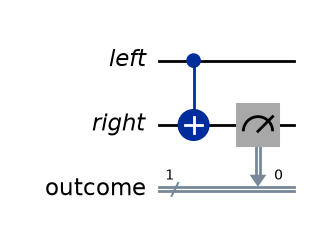

In [8]:
left_wire = QuantumRegister(1, "left")
right_wire = QuantumRegister(1, "right")
branch_bit = ClassicalRegister(1, "outcome")
combiner = QuantumCircuit(left_wire, right_wire, branch_bit)
combiner.cx(left_wire[0], right_wire[0])
combiner.measure(right_wire[0], branch_bit[0])
display(combiner.draw("mpl", fold=-1))
plt.close("all")

### The target qubit reveals one bit

For $N=2^n$, the target label is $k=N/2$. Its phase is

$$
\lvert\psi_{N/2}\rangle
=\frac{\lvert0\rangle+(-1)^s\lvert1\rangle}{\sqrt2}.
$$

A Hadamard followed by a computational-basis measurement returns
$s\bmod2$ exactly in the ideal model.

Label $0$ gives $\lvert+\rangle$ independently of $s$, so those
states are discarded. The remaining task is to produce a nonzero label
whose lowest $n-1$ bits vanish.

<a id="classical"></a>
## 3. Classical section

### Organize labels into a sieve

Suppose every retained label is divisible by $2^a$. Choose a block
width $b$, and group labels by their residues modulo $2^{a+b}$.
Labels $k$ and $\ell$ in the same bucket satisfy

$$
k-\ell\equiv0\pmod{2^{a+b}}.
$$

Pair disjoint qubits within each bucket and call the quantum combiner.
Keep the difference branch, discard the sum branch, and discard a
zero difference. Every retained child now has at least $a+b$
trailing zero bits.

Repeat until $n-1$ low bits have been cleared. The only possible
nonzero final label is $N/2$, so an X-basis measurement gives the parity.
Unpaired qubits are discarded at each level.

The classical code below selects pairs using only labels and controls
the requested quantum operations. A finite pool can run out, in which
case the attempt returns failure and a fresh pool may be prepared.

In [9]:
def sieve_parity(source, batch_size, rng, block_bits=None):
    '''One bounded sieve attempt. The controller uses labels and measured bits.'''
    n = power_two_width(source.N)
    if type(batch_size) is not int or batch_size < 1:
        raise ValueError("batch_size must be a positive integer.")
    if block_bits is None:
        block_bits = max(1, isqrt(n - 1))
        if block_bits * block_bits < n - 1:
            block_bits += 1
    if type(block_bits) is not int or block_bits < 1:
        raise ValueError("block_bits must be a positive integer.")
    pool = [source.sample() for _ in range(batch_size)]
    pool = [qubit for qubit in pool if qubit.label != 0]
    history = [{"cleared_bits": 0, "retained": len(pool),
                "pairs": 0, "difference_outcomes": 0}]
    cleared = 0
    while cleared < n - 1:
        width = min(block_bits, n - 1 - cleared)
        modulus = 1 << (cleared + width)
        buckets = defaultdict(list)
        for qubit in pool:
            if qubit.label % (1 << cleared):
                raise ArithmeticError("A sieve invariant was violated.")
            buckets[qubit.label % modulus].append(qubit)

        next_pool = []
        pairs = differences = 0
        for bucket in buckets.values():
            while len(bucket) >= 2:
                left, right = bucket.pop(), bucket.pop()
                outcome, child = combine_phase_qubits(left, right, source.N, rng)
                pairs += 1
                if outcome == 1:
                    differences += 1
                    if child.label != 0:
                        if child.label % modulus:
                            raise ArithmeticError("The difference did not clear the selected bits.")
                        next_pool.append(child)
            # Unpaired qubits are discarded at this level.
        pool = next_pool
        cleared += width
        history.append({"cleared_bits": cleared, "retained": len(pool),
                        "pairs": pairs, "difference_outcomes": differences})
        if not pool:
            return None, history

    target = source.N // 2
    if any(qubit.label != target for qubit in pool):
        raise ArithmeticError("The final pool contains an unexpected label.")
    return (measure_x_bit(pool[0], rng) if pool else None), history

### Recover the remaining bits by restricting the oracle

After learning $p=s\bmod2$, write $s=p+2s'$. The map

$$
\phi_p(x,b)=(2x+pb,b)
$$

embeds $D_{N/2}$ into the subgroup of $D_N$ containing $H_s$.
The restricted function $f_p=f\circ\phi_p$ hides
$\{(0,0),(s',1)\}$.

More generally, after recovering the lowest $t$ bits, let

$$
u=s\bmod2^t.
$$

On $D_{N/2^t}$, use

$$
f_t(x,b)=f(2^t x+ub,b).
$$

For the example oracle this gives

$$
f_t(x,b)=\pi\left(
2^t\left(x-b\frac{s-u}{2^t}\right)\bmod N
\right),
$$

so the next parity measurement reveals bit $t$ of $s$.
The restriction depends only on the already recovered prefix $u$.
No unknown higher bit is used to construct it.

The implementation uses bounded attempts for each bit and verifies the
completed reflection against the original oracle.

In [10]:
def recover_hidden_reflection(N, oracle, batch_size=256, attempts_per_bit=4, seed=2026):
    '''Recover all bits using subgroup restrictions and verify the final reflection.'''
    n = power_two_width(N)
    if N > 64:
        raise ValueError("The explicit lookup demonstration supports N <= 64.")
    if type(batch_size) is not int or batch_size < 1:
        raise ValueError("batch_size must be positive.")
    if type(attempts_per_bit) is not int or attempts_per_bit < 1:
        raise ValueError("attempts_per_bit must be positive.")
    rng = np.random.default_rng(seed)
    prefix = 0
    records = []
    preparations = table_evaluations = 0

    for bit_index in range(n):
        stride = 1 << bit_index
        local_N = N // stride

        def restricted(x, b, stride=stride, prefix=prefix):
            return oracle(stride * x + prefix * b, b)

        source = CircuitPhaseSource(local_N, restricted, rng)
        table_evaluations += 2 * local_N
        attempt_histories = []
        parity = None
        for attempt in range(attempts_per_bit):
            parity, history = sieve_parity(source, batch_size, rng)
            attempt_histories.append(history)
            if parity is not None:
                break
        preparations += source.preparations
        if parity is None:
            raise RuntimeError(f"Sieve budget exhausted while recovering bit {bit_index}.")
        prefix += parity * stride
        records.append({"bit_index": bit_index, "local_N": local_N, "bit": parity,
                        "prefix": prefix, "attempts": attempt + 1,
                        "sieves": attempt_histories})

    if oracle(prefix, 1) != oracle(0, 0):
        raise RuntimeError("The candidate reflection failed the oracle check.")
    return {"s": prefix, "subgroup": [(0, 0), (prefix, 1)],
            "preparations": preparations, "lookup_table_evaluations": table_evaluations,
            "verification_evaluations": 2, "bits": records}

### Complete recovery

The bits are recovered from least significant to most significant.
The printed prefix shows the value determined after each successful
subgroup restriction. The final equality check uses the original
hiding oracle.

In [11]:
result = recover_hidden_reflection(N, oracle, batch_size=256,
                                   attempts_per_bit=4, seed=2026)
for row in result["bits"]:
    print(f"bit {row['bit_index']}: subgroup D_{row['local_N']}, "
          f"measured {row['bit']}, prefix {row['prefix']}, "
          f"attempts {row['attempts']}")
print("Recovered reflection:", result["s"])
print("Binary reflection:", format(result["s"], f"0{power_two_width(N)}b"))
print("Hidden subgroup:", result["subgroup"])
print("Fresh phase-state preparations:", result["preparations"])
print("Classical evaluations for lookup tables:", result["lookup_table_evaluations"])
assert result["s"] == hidden_s
assert oracle(result["s"], 1) == oracle(0, 0)

bit 0: subgroup D_32, measured 1, prefix 1, attempts 1
bit 1: subgroup D_16, measured 1, prefix 3, attempts 1
bit 2: subgroup D_8, measured 0, prefix 3, attempts 1
bit 3: subgroup D_4, measured 0, prefix 3, attempts 1
bit 4: subgroup D_2, measured 1, prefix 19, attempts 1
Recovered reflection: 19
Binary reflection: 10011
Hidden subgroup: [(0, 0), (19, 1)]
Fresh phase-state preparations: 1280
Classical evaluations for lookup tables: 124


The plot below follows the first sieve attempt for the least significant
bit. The population decreases because each combination consumes two
parents, the sum branch is discarded, and some differences are zero.
The final retained states have label $N/2$.

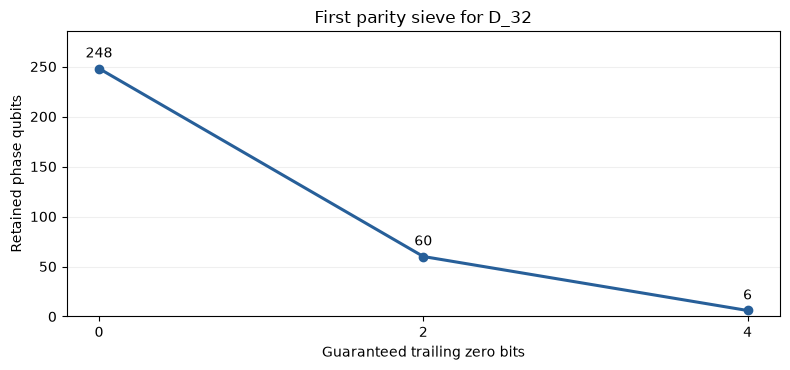

In [12]:
history = result["bits"][0]["sieves"][0]
cleared = [row["cleared_bits"] for row in history]
populations = [row["retained"] for row in history]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(cleared, populations, marker="o", linewidth=2.2, color="#275f99")
for x, y in zip(cleared, populations):
    ax.annotate(str(y), (x, y), xytext=(0, 8), textcoords="offset points", ha="center")
ax.set(xlabel="Guaranteed trailing zero bits", ylabel="Retained phase qubits",
       title="First parity sieve for D_32", xticks=cleared)
ax.set_ylim(0, max(populations) * 1.15)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

### Additional examples and a bounded failure

A zero reflection parameter still describes a nontrivial reflection
subgroup. It must be recovered rather than treated as absence of a
hidden subgroup.

A pool of one qubit cannot perform the first pairing level for $N=8$.
The final example checks that the routine reports budget exhaustion
instead of inventing a reflection.

In [13]:
for modulus, secret in ((8, 0), (8, 7), (16, 10)):
    test_oracle = make_hidden_reflection(modulus, secret, seed=secret + 17)
    found = recover_hidden_reflection(modulus, test_oracle, seed=31)
    print(f"N={modulus}: recovered s={found['s']}")
    assert found["s"] == secret

try:
    recover_hidden_reflection(8, make_hidden_reflection(8, 3),
                              batch_size=1, attempts_per_bit=1, seed=5)
except RuntimeError as error:
    print("Expected bounded failure:", error)
else:
    raise AssertionError("A single qubit cannot complete the first sieve.")

N=8: recovered s=0


N=8: recovered s=7


N=16: recovered s=10
Expected bounded failure: Sieve budget exhausted while recovering bit 0.


<a id="cost"></a>
## 4. Success and computational cost

### Why the sieve is subexponential

With block width $b$, there are at most $2^b$ buckets at each level
because the previously cleared low bits are already zero.
When the pool is much larger than the bucket count, nearly all states
can be paired. Pairing halves the population, and retaining only
difference outcomes roughly halves it again, before zero differences
are discarded.

There are approximately $(n-1)/b$ levels. A population on the scale

$$
2^{O(b+n/b)}
$$

balances the bucket count and loss across levels. Choosing
$b=\Theta(\sqrt n)$ gives the characteristic complexity

$$
2^{O(\sqrt n)}=2^{O(\sqrt{\log N})}.
$$

This population argument explains the scale. The probability estimates
and rigorous resource bounds are established in
[Kuperberg's paper](https://arxiv.org/abs/quant-ph/0302112).
The original sieve uses subexponential quantum memory as well as time
and queries. Its bound is not polynomial in the input length.

Our batch size of $256$ is chosen for small examples. It is not a
universal success guarantee or a replacement for the asymptotic
population analysis. A successful target measurement is exact for an
ideal state. Finite pools can fail, and the code bounds its retries.

### Costs for a specified pool

Let $L$ be the initial pool size for one parity attempt, and let
$C_f(n,m)$ count an oracle evaluation with an $m$-qubit output register.
Preparing the pool costs

$$
O\!\left(L\bigl(C_f(n,m)+n^2\bigr)\right)
$$

quantum gates in a model with exact one-qubit rotations. There are fewer
than $L$ combinations because each consumes two states and returns at
most one. Each combination uses one CNOT and one measurement.

The pool stores $L$ phase qubits and $O(Ln)$ classical label bits,
in addition to the preparation workspace. The total number of states
processed across levels is at most $2L$. Sorting labels into buckets
therefore gives an $O(Ln\log L)$ classical bit-operation upper bound
using comparison sorting. The dictionary implementation instead uses
hashing.

Full reflection recovery uses $n$ parity problems on successively
smaller groups. Its preparation count is the sum over those problems
and all attempted pools. If every problem allows at most $A$ attempts
of size $L$, at most $nAL$ fresh preparations are requested.
A hardware resource estimate must also account for memory lifetime,
routing, and the chosen precision for Fourier rotations.

### Costs of the local demonstration

For a domain $D_M$, explicit compilation evaluates the classical oracle
on all $2M$ inputs. Across the power-of-two subgroup restrictions, this
uses

$$
2N+2(N/2)+\cdots+2(2)=4N-4
$$

classical function evaluations, plus two for final verification.
The Boolean transform takes $O(Mm\log M)$ bit operations and emits at
most $2Mm$ controlled-NOT terms, before decomposing their controls.

The phase-source simulator stores $2^{n+1+m}$ complex amplitudes.
Each retained phase qubit is subsequently stored separately, and each
combination uses only a two-qubit statevector. This representation is
valid because the measured combination leaves one qubit and different
pairs are independent.

The explicit tables and statevector preparations are exponential in the
register widths. The notebook therefore demonstrates the quantum
mechanism and classical control on small inputs, rather than the
asymptotic speedup of a supplied-oracle quantum implementation.

## 5. Further reading

- [Greg Kuperberg, A subexponential-time quantum algorithm for the dihedral hidden subgroup problem](https://arxiv.org/abs/quant-ph/0302112), especially the basic power-of-two sieve.
- [Andrew Childs and Wim van Dam, Quantum algorithms for algebraic problems](https://arxiv.org/abs/0812.0380), Sections VII and VIII.
- [Oded Regev, A Subexponential Time Algorithm for the Dihedral Hidden Subgroup Problem with Polynomial Space](https://arxiv.org/abs/quant-ph/0406151), a related space-saving variation.
- [Qiskit Statevector](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector) and [QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate).

Return to [Beyond Finite Abelian Hidden Subgroups](../README.md).